# 03 — Hypothesis Testing

This notebook evaluates the Vanguard A/B test using completion rate, error rate, and session duration.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)


## Load clean data

In [2]:
df = pd.read_csv("processed_data/clean_vanguard_data.csv")
session_data = pd.read_csv("processed_data/session_vanguard_data.csv")

error_by_variation = pd.read_csv("processed_data/error_by_variation.csv")
error_by_step = pd.read_csv("processed_data/error_by_step.csv")
error_by_age = pd.read_csv("processed_data/error_by_age.csv")

client_level_usage = pd.read_csv("processed_data/client_level_usage.csv")
calls_logons_by_variation = pd.read_csv("processed_data/calls_logons_by_variation.csv")
calls_logons_by_age = pd.read_csv("processed_data/calls_logons_by_age.csv")
calls_logons_by_age_gender = pd.read_csv("processed_data/calls_logons_by_age_gender.csv")

df.head()

,client_id,visitor_id,visit_id,process_step,date_time,step_num,date,time,hour,weekday,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,variation,completed,session_duration_seconds,max_step,previous_step_num,previous_step,step_diff,is_error,error_type
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,0,2017-04-15,12:57:56,12,Saturday,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,18-34,test,True,158.0,4,NaN,NaN,NaN,False,first_step
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,1,2017-04-15,12:58:03,12,Saturday,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,18-34,test,True,158.0,4,0.0,start,1.0,False,valid
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2,2017-04-15,12:58:35,12,Saturday,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,18-34,test,True,158.0,4,1.0,step_1,1.0,False,valid
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,3,2017-04-15,13:00:14,13,Saturday,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,18-34,test,True,158.0,4,2.0,step_2,1.0,False,valid
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,4,2017-04-15,13:00:34,13,Saturday,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,18-34,test,True,158.0,4,3.0,step_3,1.0,False,valid


In [3]:

print("Dataset shape:", df.shape)
display(df["variation"].value_counts())


Dataset shape: (315686, 28)


variation
test       175898
control    139788
Name: count, dtype: int64

## Prepare data

In [4]:

df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

step_mapping = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["process_step"] = df["process_step"].str.lower().str.strip()
df["step_num"] = df["process_step"].map(step_mapping)


## Create session-level data

In [5]:
session_data["first_timestamp"] = pd.to_datetime(session_data["first_timestamp"], errors="coerce")
session_data["last_timestamp"] = pd.to_datetime(session_data["last_timestamp"], errors="coerce")

session_data["completed"] = session_data["completed"].astype(bool)

session_data.head()

,variation,client_id,visitor_id,visit_id,max_step,first_timestamp,last_timestamp,number_of_steps,completed,session_duration_seconds
0,control,1028,42237450_62128060588,557292053_87239438319_391157,3,2017-04-08 18:51:28,2017-04-08 19:00:26,9,False,538.0
1,control,1104,194240915_18158000533,543158812_46395476577_767725,0,2017-06-12 07:49:18,2017-06-12 07:49:18,1,False,0.0
2,control,1104,194240915_18158000533,643221571_99977972121_69283,0,2017-06-20 22:31:33,2017-06-20 22:31:33,1,False,0.0
3,control,1186,446844663_31615102958,507052512_11309370126_442139,0,2017-04-08 15:59:16,2017-04-08 15:59:16,1,False,0.0
4,control,1186,446844663_31615102958,795373564_99931517312_810896,2,2017-04-08 18:05:02,2017-04-08 18:05:24,3,False,22.0



# Hypothesis Test 1 — Completion Rate

## Research Question

Did the new digital interface increase completion rate?

## Metric

Completion rate = completed sessions / total sessions

A session is completed when the user reaches the `confirm` step.

## Hypotheses

H₀: Completion rate is equal between control and test groups.

H₁: Completion rate is different between control and test groups.

Statistical test: two-proportion z-test.


In [6]:

completion_summary = (
    session_data
    .groupby("variation")
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

completion_summary["completion_rate"] = (
    completion_summary["completed_sessions"] /
    completion_summary["total_sessions"]
)

completion_summary["completion_rate_percent"] = (
    completion_summary["completion_rate"] * 100
)

completion_summary


,variation,total_sessions,completed_sessions,completion_rate,completion_rate_percent
0,control,32115,15979,0.497556,49.755566
1,test,37070,21677,0.584759,58.475856


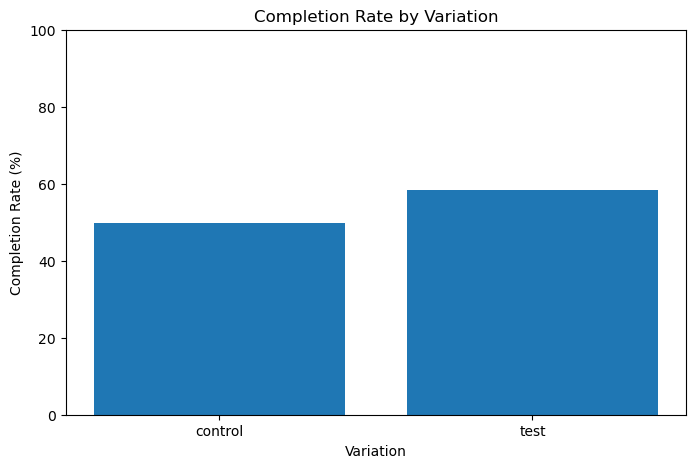

In [7]:

plt.figure(figsize=(8, 5))

plt.bar(
    completion_summary["variation"],
    completion_summary["completion_rate_percent"]
)

plt.title("Completion Rate by Variation")
plt.xlabel("Variation")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 100)

plt.show()


In [8]:

control = completion_summary[completion_summary["variation"] == "control"]
test = completion_summary[completion_summary["variation"] == "test"]

n_control = control["total_sessions"].values[0]
n_test = test["total_sessions"].values[0]

x_control = control["completed_sessions"].values[0]
x_test = test["completed_sessions"].values[0]

z_stat, p_value = proportions_ztest(
    [x_control, x_test],
    [n_control, n_test]
)

print("Control completed sessions:", x_control)
print("Control total sessions:", n_control)
print("Control completion rate:", round(x_control / n_control, 4))

print("Test completed sessions:", x_test)
print("Test total sessions:", n_test)
print("Test completion rate:", round(x_test / n_test, 4))

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))


Control completed sessions: 15979
Control total sessions: 32115
Control completion rate: 0.4976
Test completed sessions: 21677
Test total sessions: 37070
Test completion rate: 0.5848
Z-statistic: -22.9684
P-value: 0.0


In [9]:

alpha = 0.05

if p_value < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in completion rates.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say completion rates are significantly different.")


Reject H0.
There is a statistically significant difference in completion rates.


In [10]:

control_rate = x_control / n_control
test_rate = x_test / n_test

absolute_lift = test_rate - control_rate
relative_lift = absolute_lift / control_rate

print("Control completion rate:", round(control_rate * 100, 2), "%")
print("Test completion rate:", round(test_rate * 100, 2), "%")
print("Absolute lift:", round(absolute_lift * 100, 2), "percentage points")
print("Relative lift:", round(relative_lift * 100, 2), "%")


Control completion rate: 49.76 %
Test completion rate: 58.48 %
Absolute lift: 8.72 percentage points
Relative lift: 17.53 %


In [11]:
completion_age = (
    session_data
    .merge(
        df[["client_id", "age_group"]].drop_duplicates(),
        on="client_id",
        how="left"
    )
    .groupby(["age_group", "variation"])
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

completion_age["completion_rate"] = (
    completion_age["completed_sessions"] / completion_age["total_sessions"]
)

completion_age["completion_rate_percent"] = completion_age["completion_rate"] * 100

completion_age

,age_group,variation,total_sessions,completed_sessions,completion_rate,completion_rate_percent
0,18-34,control,8253,4426,0.536290,53.628983
1,18-34,test,9623,6038,0.627455,62.745506
2,35-44,control,5124,2736,0.533958,53.395785
3,35-44,test,5848,3601,0.615766,61.576607
4,45-54,control,6186,3215,0.519722,51.972195
5,45-54,test,7348,4274,0.581655,58.165487
6,55-64,control,7299,3505,0.480203,48.020277
7,55-64,test,8253,4654,0.563916,56.391615
8,65+,control,5215,2069,0.396740,39.674017
9,65+,test,5953,3072,0.516042,51.604233



## Completion Rate Conclusion

Use the p-value and lift above to decide whether the new interface created a meaningful improvement.

If p-value < 0.05, the difference is statistically significant.

If p-value >= 0.05, there is not enough statistical evidence to confirm a difference.


In [12]:
print("Control completion rate:", round(control_rate * 100, 2), "%")
print("Test completion rate:", round(test_rate * 100, 2), "%")
print("Absolute lift:", round(absolute_lift * 100, 2), "percentage points")
print("Relative lift:", round(relative_lift * 100, 2), "%")

Control completion rate: 49.76 %
Test completion rate: 58.48 %
Absolute lift: 8.72 percentage points
Relative lift: 17.53 %


# Completion Rate by Age Group

## Research Question

Did the new interface improve completion rates differently across age groups?

## Metric

Completion rate segmented by `age_group` and `variation`.

This helps identify whether certain age groups benefit more from the redesign.

In [13]:
completion_age = (
    session_data
    .merge(
        df[["client_id", "age_group"]].drop_duplicates(),
        on="client_id",
        how="left"
    )
    .groupby(["age_group", "variation"])
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

completion_age["completion_rate"] = (
    completion_age["completed_sessions"] / completion_age["total_sessions"]
)

completion_age["completion_rate_percent"] = completion_age["completion_rate"] * 100

completion_age

,age_group,variation,total_sessions,completed_sessions,completion_rate,completion_rate_percent
0,18-34,control,8253,4426,0.536290,53.628983
1,18-34,test,9623,6038,0.627455,62.745506
2,35-44,control,5124,2736,0.533958,53.395785
3,35-44,test,5848,3601,0.615766,61.576607
4,45-54,control,6186,3215,0.519722,51.972195
5,45-54,test,7348,4274,0.581655,58.165487
6,55-64,control,7299,3505,0.480203,48.020277
7,55-64,test,8253,4654,0.563916,56.391615
8,65+,control,5215,2069,0.396740,39.674017
9,65+,test,5953,3072,0.516042,51.604233


In [14]:
age_order = ["18-34", "35-44", "45-54", "55-64", "65+"]

# Ensure correct ordering
completion_age["age_group"] = pd.Categorical(
    completion_age["age_group"],
    categories=age_order,
    ordered=True
)

# Create clean pivot table
completion_age_table = (
    completion_age
    .pivot(
        index="age_group",
        columns="variation",
        values="completion_rate_percent"
    )
    .reindex(age_order)
    .round(2)
)

# Optional: rename columns for clarity
completion_age_table.columns = ["Control (%)", "Test (%)"]

completion_age_table

,Control (%),Test (%)
age_group,,
18-34,53.63,62.75
35-44,53.40,61.58
45-54,51.97,58.17
55-64,48.02,56.39
65+,39.67,51.60


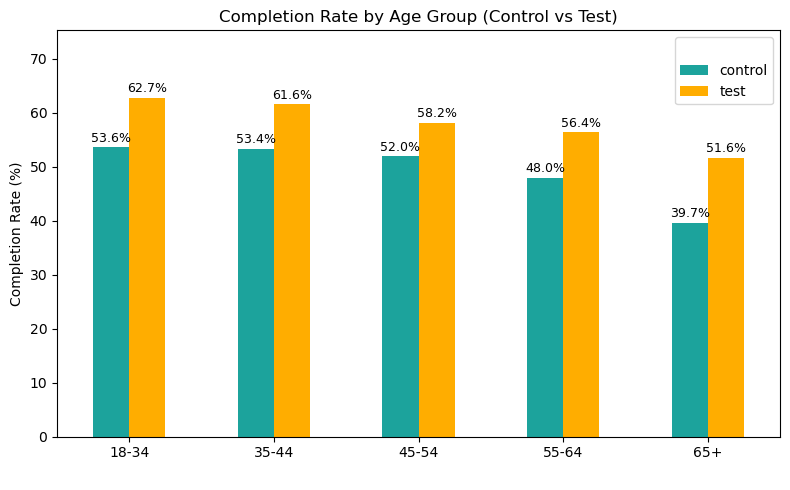

In [15]:
# Step 1: create ordered age groups
age_order = ["18-34", "35-44", "45-54", "55-64", "65+"]

completion_age["age_group"] = pd.Categorical(
    completion_age["age_group"],
    categories=age_order,
    ordered=True
)

# Step 2: pivot for plotting
completion_age_pivot = completion_age.pivot(
    index="age_group",
    columns="variation",
    values="completion_rate_percent"
).reindex(age_order)

# Step 3: plot
ax = completion_age_pivot.plot(
    kind="bar",
    figsize=(8, 5),
    color=["#1ca39c", "#ffad00"]
)

# Step 4: labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.title("Completion Rate by Age Group (Control vs Test)")
plt.xlabel(" ")
plt.ylabel("Completion Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, completion_age_pivot.max().max() * 1.2)
plt.legend(title=" ")
plt.tight_layout()
plt.show()

In [16]:
completion_age_lift = completion_age.pivot(
    index="age_group",
    columns="variation",
    values="completion_rate"
).reindex(age_order)

completion_age_lift["lift"] = completion_age_lift["test"] - completion_age_lift["control"]
completion_age_lift["lift_percentage_points"] = completion_age_lift["lift"] * 100

completion_age_lift

variation,control,test,lift,lift_percentage_points
age_group,,,,
18-34,0.536290,0.627455,0.091165,9.116522
35-44,0.533958,0.615766,0.081808,8.180823
45-54,0.519722,0.581655,0.061933,6.193292
55-64,0.480203,0.563916,0.083713,8.371338
65+,0.396740,0.516042,0.119302,11.930216



# Hypothesis Test 2 — Error Rate

## Research Question

Did the new interface reduce user errors?

## Metric

Error rate = backward movements / total actions

A backward movement happens when the user moves from a later step to an earlier step.

Examples:

- step_3 → step_2
- step_2 → step_1
- step_1 → start

Statistical test: two-proportion z-test.


In [17]:
error_by_variation

,variation,total_actions,total_errors,error_rate,error_rate_percent
0,control,139788,9913,0.070915,7.09
1,test,175898,16997,0.096630,9.66


In [18]:

error_summary = (
    df_sorted
    .groupby("variation")
    .agg(
        total_actions=("process_step", "count"),
        total_errors=("is_error", "sum")
    )
    .reset_index()

)

error_summary["error_rate"] = round(
    error_summary["total_errors"] /
    error_summary["total_actions"]
    ,4
)

error_summary["error_rate_percent"] = round(error_summary["error_rate"] * 100,2)

error_summary


NameError: name 'df_sorted' is not defined

In [ ]:
control_error = error_by_variation[error_by_variation["variation"] == "control"]
test_error = error_by_variation[error_by_variation["variation"] == "test"]

n_control_error = control_error["total_actions"].values[0]
n_test_error = test_error["total_actions"].values[0]

x_control_error = control_error["total_errors"].values[0]
x_test_error = test_error["total_errors"].values[0]

z_stat_error, p_value_error = proportions_ztest(
    [x_control_error, x_test_error],
    [n_control_error, n_test_error]
)

print("Control error rate:", round(x_control_error / n_control_error * 100, 2), "%")
print("Test error rate:", round(x_test_error / n_test_error * 100, 2), "%")
print("Z-statistic:", round(z_stat_error, 4))
print("P-value:", round(p_value_error, 4))

Control error rate: 7.09 %
Test error rate: 9.66 %
Z-statistic: -25.7009
P-value: 0.0


In [ ]:

if p_value_error < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in error rates.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say error rates are significantly different.")


Reject H0.
There is a statistically significant difference in error rates.



# Hypothesis Test 3 — Session Duration

## Research Question

Did users in the test group complete sessions faster or slower?

## Metric

Session duration in seconds.

Statistical test: independent two-sample t-test.


In [ ]:

duration_data = session_data.copy()

duration_data = duration_data[
    duration_data["session_duration_seconds"].notna()
]

duration_data = duration_data[
    duration_data["session_duration_seconds"] >= 0
]

q1 = duration_data["session_duration_seconds"].quantile(0.25)
q3 = duration_data["session_duration_seconds"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

duration_no_outliers = duration_data[
    (duration_data["session_duration_seconds"] >= lower_bound) &
    (duration_data["session_duration_seconds"] <= upper_bound)
]

print("Original duration rows:", len(duration_data))
print("Rows after outlier removal:", len(duration_no_outliers))


Original duration rows: 69185
Rows after outlier removal: 63902


In [ ]:

duration_summary = (
    duration_no_outliers
    .groupby("variation")
    .agg(
        average_duration=("session_duration_seconds", "mean"),
        median_duration=("session_duration_seconds", "median"),
        session_count=("session_duration_seconds", "count")
    )
    .reset_index()
)

duration_summary


,variation,average_duration,median_duration,session_count
0,control,187.734041,141.0,29873
1,test,195.935173,149.0,34029


In [ ]:

control_duration = duration_no_outliers[
    duration_no_outliers["variation"] == "control"
]["session_duration_seconds"]

test_duration = duration_no_outliers[
    duration_no_outliers["variation"] == "test"
]["session_duration_seconds"]

t_stat, p_value_duration = ttest_ind(
    control_duration,
    test_duration,
    equal_var=False
)

print("Control average duration:", round(control_duration.mean(), 2))
print("Test average duration:", round(test_duration.mean(), 2))
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value_duration, 4))


Control average duration: 187.73
Test average duration: 195.94
T-statistic: -5.4356
P-value: 0.0


In [ ]:

if p_value_duration < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in average session duration.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say average session duration is significantly different.")


Reject H0.
There is a statistically significant difference in average session duration.



# Hypothesis Test 4 — Digital Engagement

## Research Question

Did the redesigned digital experience increase customer engagement with Vanguard’s digital platform?

## Metric

Digital engagement is measured using client contact/activity over the last 6 months.

For this analysis, the main variable is:

`calls_6_mnth`

This represents the number of calls/interactions recorded for a client in the last 6 months.

## Hypotheses

H₀: The average digital engagement is equal between the control and test groups.

H₁: The average digital engagement is different between the control and test groups.

Statistical test: independent two-sample t-test.


In [ ]:
engagement_data = client_level_usage.copy()

engagement_data = engagement_data[
    engagement_data["calls_6_mnth"].notna()
]

engagement_data = engagement_data[
    engagement_data["variation"].isin(["control", "test"])
]

calls_logons_by_variation

,variation,average_calls_6_mnth,median_calls_6_mnth,average_logons_6_mnth,median_logons_6_mnth,total_clients
0,control,3.13,3.0,6.17,6.0,23435
1,test,3.06,3.0,6.10,6.0,26866


In [ ]:
control_engagement = engagement_data[
    engagement_data["variation"] == "control"
]["calls_6_mnth"]

test_engagement = engagement_data[
    engagement_data["variation"] == "test"
]["calls_6_mnth"]

t_stat_engagement, p_value_engagement = ttest_ind(
    control_engagement,
    test_engagement,
    equal_var=False
)

print("Control average calls in last 6 months:", round(control_engagement.mean(), 2))
print("Test average calls in last 6 months:", round(test_engagement.mean(), 2))
print("T-statistic:", round(t_stat_engagement, 4))
print("P-value:", round(p_value_engagement, 4))

Control average calls in last 6 months: 3.13
Test average calls in last 6 months: 3.06
T-statistic: 3.5147
P-value: 0.0004


In [ ]:

alpha = 0.05

if p_value_engagement < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in digital engagement between groups.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say digital engagement is significantly different between groups.")


Reject H0.
There is a statistically significant difference in digital engagement between groups.


In [ ]:
alpha = 0.05

print("========== FINAL RESULTS ==========")

# =========================
# COMPLETION RATE
# =========================
print("\nCOMPLETION RATE")

control_rate = x_control / n_control
test_rate = x_test / n_test
absolute_lift = test_rate - control_rate

print(f"Control: {round(control_rate*100,2)}%")
print(f"Test: {round(test_rate*100,2)}%")
print(f"Lift: {round(absolute_lift*100,2)} percentage points")
print(f"P-value: {round(p_value,4)}")

if p_value < alpha:
    direction = "increase" if test_rate > control_rate else "decrease"
    print(f"Result: Statistically significant ({direction})")
else:
    print("Result: NOT statistically significant")


# =========================
# ERROR RATE
# =========================
print("\nERROR RATE")

control_err_rate = x_control_error / n_control_error
test_err_rate = x_test_error / n_test_error

print(f"Control: {round(control_err_rate*100,2)}%")
print(f"Test: {round(test_err_rate*100,2)}%")
print(f"P-value: {round(p_value_error,4)}")

if p_value_error < alpha:
    direction = "increase" if test_err_rate > control_err_rate else "decrease"
    print(f"Result: Statistically significant ({direction})")
else:
    print("Result: NOT statistically significant")


# =========================
# SESSION DURATION
# =========================
print("\nSESSION DURATION")

control_avg = control_duration.mean()
test_avg = test_duration.mean()

print(f"Control avg: {round(control_avg,2)} sec")
print(f"Test avg: {round(test_avg,2)} sec")
print(f"P-value: {round(p_value_duration,4)}")

if p_value_duration < alpha:
    direction = "increase" if test_avg > control_avg else "decrease"
    print(f"Result: Statistically significant ({direction})")
else:
    print("Result: NOT statistically significant")


# =========================
# DIGITAL ENGAGEMENT
# =========================
print("\nDIGITAL ENGAGEMENT")

control_calls = control_engagement.mean()
test_calls = test_engagement.mean()

lift_calls = test_calls - control_calls

print(f"Control avg calls: {round(control_calls,2)}")
print(f"Test avg calls: {round(test_calls,2)}")
print(f"Difference: {round(lift_calls,2)} calls")
print(f"P-value: {round(p_value_engagement,4)}")

if p_value_engagement < alpha:
    direction = "increase" if test_calls > control_calls else "decrease"
    print(f"Result: Statistically significant ({direction})")
else:
    print("Result: NOT statistically significant")

========== FINAL RESULTS ==========

COMPLETION RATE
Control: 49.76%
Test: 58.48%
Lift: 8.72 percentage points
P-value: 0.0
Result: Statistically significant (increase)

ERROR RATE
Control: 7.09%
Test: 9.66%
P-value: 0.0
Result: Statistically significant (increase)

SESSION DURATION
Control avg: 187.73 sec
Test avg: 195.94 sec
P-value: 0.0
Result: Statistically significant (increase)

DIGITAL ENGAGEMENT
Control avg calls: 3.13
Test avg calls: 3.06
Difference: -0.07 calls
P-value: 0.0004
Result: Statistically significant (decrease)


# Final Conclusion

## Completion Rate

The test group shows a completion rate of **58.48%**, compared to **49.76%** in the control group, resulting in a lift of **8.72 percentage points**.

The p-value is **< 0.001**, indicating that the difference is **statistically significant**.

This shows that the redesigned interface **significantly improves the likelihood of users completing the process**.

---

## Error Rate

The error rate in the test group is **9.66%**, compared to **7.09%** in the control group.

The p-value is **< 0.001**, indicating that the difference is **statistically significant**.

This means the redesign **significantly increases user errors**, suggesting that the new interface introduces **more friction or confusion in the user journey**.

---

## Session Duration

The average session duration is **195.94 seconds** for the test group and **187.73 seconds** for the control group.

The p-value is **< 0.001**, indicating that the difference is **statistically significant**.

This suggests that users take **longer to complete the process** with the redesigned interface, which may indicate **reduced efficiency or increased complexity**.

---

## Digital Engagement

The average number of calls in the last 6 months is **3.06** for the test group and **3.13** for the control group.

The p-value is **0.0004**, indicating that the difference is **statistically significant**.

In this context, calls are interpreted as **requests for help or support**. Therefore, a lower number of calls suggests that users experience **fewer difficulties when using the platform**.

This indicates that the redesigned interface **reduces the need for user assistance**, which is a positive outcome and reflects **improved usability**.

---

## Final Decision

The redesigned interface leads to:

- ✅ A **significant increase in completion rate**
- ❌ A **significant increase in error rate**
- ❌ A **longer session duration**
- ✅ A **significant decrease in help-related calls (improved usability)**

👉 These results show **mixed outcomes**:

- The redesign is effective at helping users **complete the process**
- It also reduces **explicit help-seeking behavior**
- However, it introduces **more errors and increases time spent**, suggesting possible **confusion or inefficiencies**

### Final Verdict:

👉 The redesign is **PARTIALLY VALIDATED but not fully optimized**.

It shows strong improvements in completion and reduced support needs, but the increase in errors and session duration indicates that **further refinement is necessary before full implementation**.